In [40]:
"""
Funciones que calculan métodos numéricos
"""


import sympy as sp



def Biseccion(funcion, a, b, tolerancia):
    if funcion(a) * funcion(b) > 0:
        print('La función no cumple el teorema en el intervalo inicial')
        return None
    else:
        iteracion = 0
        while (abs(b - a) > tolerancia):
            iteracion += 1
            p = (a + b) / 2
            if (funcion(a) * funcion(p)) > 0:
                a = p
            else:
                b = p
        return iteracion, p


def falsa_posicion(funcion, a, b, tolerancia):

    if funcion(a) * funcion(b) > 0:
        print('La función no cumple el teorema en el intervalo inicial')
        return
    else:
        iteracion = 0
        p = b - funcion(b) * (a - b) / (funcion(a) - funcion(b))
        while (abs(funcion(p)) > tolerancia):
            iteracion += 1
            p = b - funcion(b) * (a - b) / (funcion(a) - funcion(b))
            if (funcion(a) * funcion(p)) > 0:
                a = p
            else:
                b = p
        return iteracion, p


def secante(funcion, x0, x1, tolerancia):
    iteraciones = 0
    error = 1
    x2 = x1  # Inicializamos x2 para evitar el UnboundLocalError
    while (error > tolerancia):
        iteraciones += 1
        denominador = funcion(x0) - funcion(x1)
        if denominador == 0: break # Evitar división por cero
        
        x2 = x1 - (funcion(x1) * (x0 - x1)) / denominador
        error = abs(x2 - x1)
        x0 = x1
        x1 = x2
        if iteraciones > 100: break # Seguridad
    return iteraciones, x2

def newton_rapshon(funcion, x0, tolerancia, x):
    derivada_funcion = sp.diff(funcion, x)
    x1 : float = x0 - (funcion.evalf(subs={x: x0}) / derivada_funcion.evalf(subs={x: x0}))
    iteraciones = 0
    while abs(x1 - x0) > tolerancia:
        iteraciones += 1
        x0 = x1
        x1 = x0 - (funcion.evalf(subs={x: x0}) / derivada_funcion.evalf(subs={x: x0}))
    return iteraciones, x1, derivada_funcion

## Corrección Examen – Frecuencias naturales de una viga voladiza

Las frecuencias naturales de una viga voladiza están relacionadas con las raíces $\beta_i$ de la ecuación de frecuencia:

$$f(\beta) = \cos(\beta)\cosh(\beta) + 1 = 0$$

donde $\beta_i = (2\pi f_i)^2 \dfrac{mL^3}{EI}$.

**Datos del problema:**
- Longitud: $L = 0.9\,\text{m}$  
- Sección rectangular: $25\,\text{mm} \times 2.5\,\text{mm}$  
- Densidad: $\rho = 7500\,\text{kg/m}^3$  
- Módulo de elasticidad: $E = 200\,\text{GPa}$  
- Masa: $m = 0.04219\,\text{kg}$  
- Momento de inercia: $I = 3.2610^{-11}\,\text{m}^4$

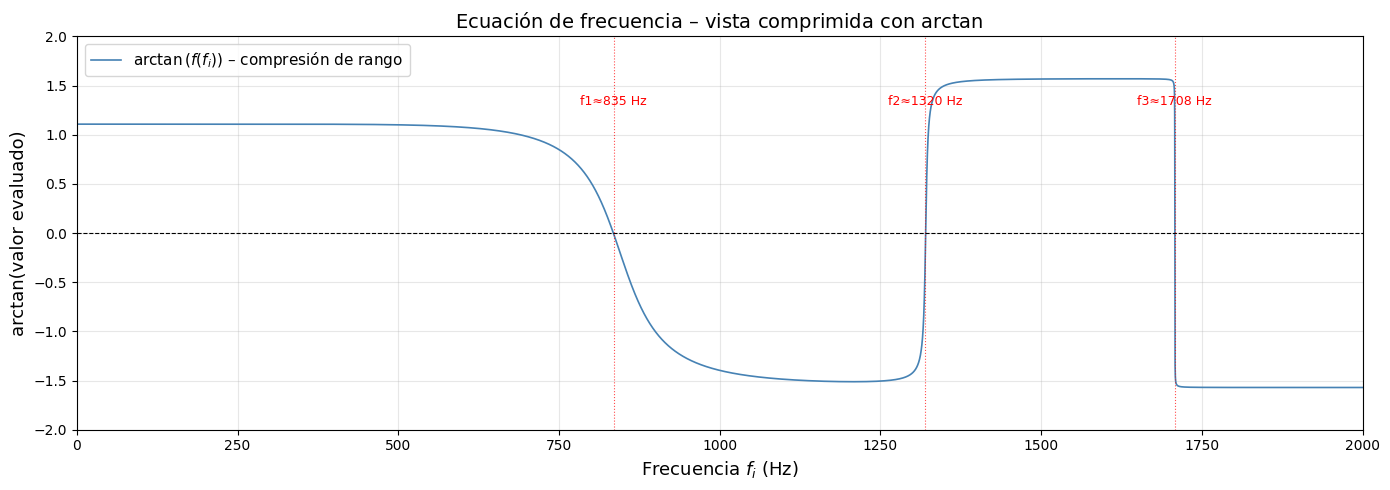

De la gráfica se observan frecuencias de raíz aproximadas en:
  f₁ ≈ 835 Hz   (primera frecuencia)
  f₂ ≈ 1320 Hz  (segunda frecuencia)
  f₃ ≈ 1708 Hz  (tercera frecuencia)


In [41]:
import numpy as np
import matplotlib.pyplot as plt

#Parametros iniciales
E = 200e9          
I = 3.2610**(-11)     
m = 0.04219        
L = 0.9            

# Definimos la función
def f_viga(f_i):
    
    beta = ((2 * np.pi * f_i)**2) * (m * L**3) / (E * I)
    return np.cos(beta) * np.cosh(beta) + 1

# ── a) Bosquejo de la función ────────────────────────
# Con I = 3.2610**(-11), las raíces caen en frecuencias mucho más altas.
# La función crece exponencialmente entre raíces (por el cosh), así que
# usamos arctan para comprimir el rango sin perder los cruces por cero.

import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings de overflow en cosh

f_vals_ampliado = np.linspace(1, 2000, 20000)
y_raw = np.array([f_viga(freq) for freq in f_vals_ampliado])

# arctan comprime (-inf, +inf) a (-pi/2, pi/2)
# Conserva exactamente los cruces por cero: arctan(0) = 0
y_compressed = np.arctan(y_raw)
y_compressed = np.where(np.isnan(y_compressed), 0, y_compressed)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(f_vals_ampliado, y_compressed, color='steelblue', linewidth=1.2,
        label=r'$\arctan\left(f(f_i)\right)$ – compresión de rango')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel(r'Frecuencia $f_i$ (Hz)', fontsize=13)
ax.set_ylabel(r'arctan(valor evaluado)', fontsize=13)
ax.set_title(r'Ecuación de frecuencia – vista comprimida con $\arctan$', fontsize=14)
ax.set_ylim(-2, 2)
ax.set_xlim(0, 2000)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Marcar las raíces aproximadas con líneas verticales
raices_aprox = [835, 1320, 1708]
for i, r in enumerate(raices_aprox, 1):
    ax.axvline(r, color='red', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.annotate(f'f{i}≈{r} Hz', xy=(r, 1.3), fontsize=9, color='red',
                ha='center')

plt.tight_layout()
plt.show()

warnings.filterwarnings('default')

print("De la gráfica se observan frecuencias de raíz aproximadas en:")
print("  f₁ ≈ 835 Hz   (primera frecuencia)")
print("  f₂ ≈ 1320 Hz  (segunda frecuencia)")
print("  f₃ ≈ 1708 Hz  (tercera frecuencia)")

In [42]:
# ── b) Una frecuencia con método ABIERTO: Secante ─────────────────────────────
#
# De la gráfica comprimida, la primera frecuencia natural se ubica cerca de f₁ ≈ 835 Hz.
# Iniciamos el método de la secante con x0 = 834.54 y x1 = 834.55.
# (Intervalo estrecho para evitar overflow en cosh)

a1, b1 = 834.54, 834.55
tolerancia = 1e-6

print("=" * 55)
print("  Método de la Secante – primera frecuencia (f₁)")
print("=" * 55)
print(f"  Puntos iniciales: x0 = {a1},  x1 = {b1}")
print(f"  Tolerancia: {tolerancia}\n")

iteraciones_sec, freq_sec = secante(f_viga, a1, b1, tolerancia)

print(f"\nResultado:")
print(f"  f₁ ≈ {freq_sec:.8f} Hz")
print(f"  Iteraciones: {iteraciones_sec}")
print(f"  Verificación f_viga(f₁) = {f_viga(freq_sec):.2e}")

  Método de la Secante – primera frecuencia (f₁)
  Puntos iniciales: x0 = 834.54,  x1 = 834.55
  Tolerancia: 1e-06


Resultado:
  f₁ ≈ 834.54526476 Hz
  Iteraciones: 2
  Verificación f_viga(f₁) = 3.23e-14


In [43]:
# ── c) Segunda frecuencia con método CERRADO: Bisección ───────────────────────
#
# De la gráfica comprimida, la segunda frecuencia se ubica cerca de f₂ ≈ 1320 Hz.
# Elegimos el intervalo [1320.42, 1320.43] donde f_viga cambia de signo.
# (Intervalo estrecho para evitar overflow en cosh)

a2, b2 = 1320.42, 1320.43

print("=" * 55)
print("  Método de Bisección – segunda frecuencia (f₂)")
print("=" * 55)
print(f"  Intervalo inicial: [{a2}, {b2}]")
print(f"  f_viga({a2}) = {f_viga(a2):.4f}")
print(f"  f_viga({b2}) = {f_viga(b2):.4f}")
print(f"  Cambio de signo: {'Sí' if f_viga(a2)*f_viga(b2) < 0 else 'No'}")
print(f"  Tolerancia: {tolerancia}\n")

iteraciones_bis, freq_bis = Biseccion(f_viga, a2, b2, tolerancia)

print(f"Resultado:")
print(f"  f₂ ≈ {freq_bis:.8f} Hz")
print(f"  Iteraciones: {iteraciones_bis}")
print(f"  Verificación f_viga(f₂) = {f_viga(freq_bis):.2e}")

  Método de Bisección – segunda frecuencia (f₂)
  Intervalo inicial: [1320.42, 1320.43]
  f_viga(1320.42) = -0.0010
  f_viga(1320.43) = 0.0028
  Cambio de signo: Sí
  Tolerancia: 1e-06

Resultado:
  f₂ ≈ 1320.42265686 Hz
  Iteraciones: 14
  Verificación f_viga(f₂) = 5.15e-08


---
## Función adicional: $f(x) = x - \tan(x)$

Aqui se nos pide lo siguiente:

Hallar las **tres primeras raíces positivas** con una función de ceros a elección.
nosotros en este caso vamos a utilizar el **método de Bisección**.

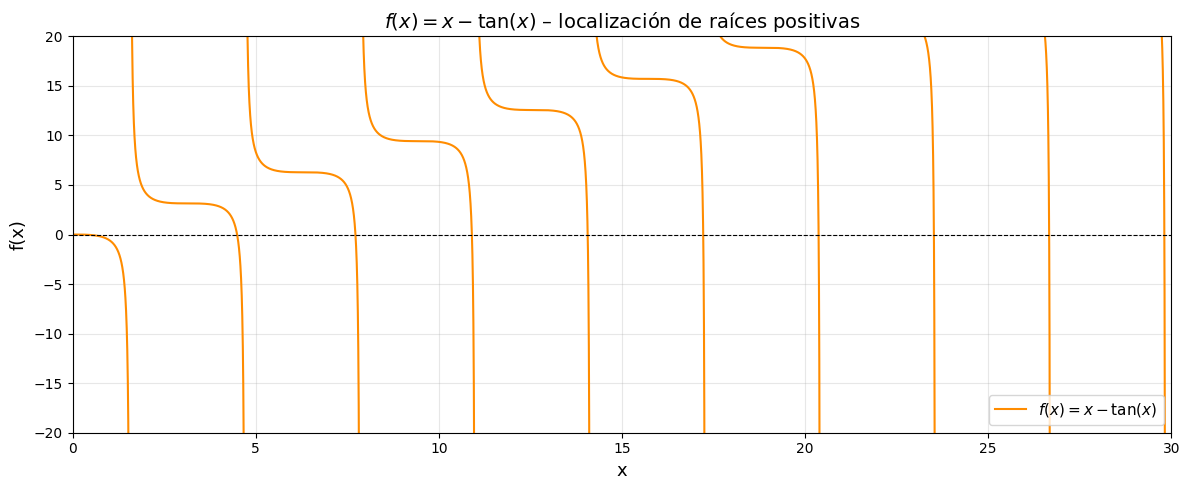

De la gráfica se observan raíces positivas no nulas cerca de:
  x₁ ≈ 4.49   (en [3.2, 4.71])
  x₂ ≈ 7.73   (en [6.4, 7.85])
  x₃ ≈ 10.90  (en [9.6, 10.99])


In [44]:
import numpy as np
import matplotlib.pyplot as plt

# ── Definición de la funcion ──────────────────────────────────────────
def f_xtan(x):
    
    return x - np.tan(x)

# ── Gráfica para visualizar las raíces ───────────────────────────────────────
x_vals = np.linspace(0.01, 30, 10000)

# Enmascarar discontinuidades
y_raw  = f_xtan(x_vals)
y_plot = np.where(np.abs(y_raw) > 50, np.nan, y_raw)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_vals, y_plot, color='darkorange', linewidth=1.5,
        label=r'$f(x) = x - \tan(x)$')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_title(r'$f(x) = x - \tan(x)$ – localización de raíces positivas', fontsize=14)
ax.set_ylim(-20, 20)
ax.set_xlim(0, 30)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("De la gráfica se observan raíces positivas no nulas cerca de:")
print("  x₁ ≈ 4.49   (en [3.2, 4.71])")
print("  x₂ ≈ 7.73   (en [6.4, 7.85])")
print("  x₃ ≈ 10.90  (en [9.6, 10.99])")

In [45]:
# ── Tres primeras raíces positivas con Bisección ──────────────────────────────
#
# Las raíces positivas no nulas de x - tan(x) = 0 se ubican justo ANTES
# de las asíntotas de nuestra función
# Eso si, los intervalos deben estar dentro de una rama
# de tan(x) para que f cambie de signo sin cruzar una discontinuidad:
#   [3.2, 4.71]  → f(3.2) > 0, f(4.71) < 0  →  x₁ ≈ 4.4934
#   [6.4, 7.85]  → f(6.4) > 0, f(7.85) < 0  →  x₂ ≈ 7.7253
#   [9.6, 10.99] → f(9.6) > 0, f(10.99) < 0 →  x₃ ≈ 10.9041

tolerancia = 1e-6
intervalos = [(3.2, 4.71), (6.4, 7.85), (9.6, 10.99)]

print("=" * 60)
print("  Tres primeras raíces positivas de f(x) = x - tan(x)")
print("  Método: Bisección")
print("=" * 60)

raices_xtan = []

for i, (a, b) in enumerate(intervalos, start=1):
    fa, fb = f_xtan(a), f_xtan(b)
    print(f"\nRaíz #{i}")
    print(f"  Intervalo: [{a}, {b}]")
    print(f"  f({a}) = {fa:.4f},  f({b}) = {fb:.4f}")
    print(f"  Cambio de signo: {'Sí' if fa * fb < 0 else 'No'}")

    resultado = Biseccion(f_xtan, a, b, tolerancia)
    if resultado:
        iters, raiz = resultado
        raices_xtan.append(raiz)
        print(f"  x_{i} ≈ {raiz:.8f}")
        print(f"  Iteraciones: {iters}")
        print(f"  Verificación f(x_{i}) = {f_xtan(raiz):.2e}")

print("\n" + "=" * 60)
print("Resumen de raíces positivas:")
for i, r in enumerate(raices_xtan, 1):
    print(f"  x_{i} = {r:.8f}")

  Tres primeras raíces positivas de f(x) = x - tan(x)
  Método: Bisección

Raíz #1
  Intervalo: [3.2, 4.71]
  f(3.2) = 3.1415,  f(4.71) = -413.8778
  Cambio de signo: Sí
  x_1 ≈ 4.49340883
  Iteraciones: 21
  Verificación f(x_1) = 1.27e-05

Raíz #2
  Intervalo: [6.4, 7.85]
  f(6.4) = 6.2827,  f(7.85) = -243.3018
  Cambio de signo: Sí
  x_2 ≈ 7.72525165
  Iteraciones: 21
  Verificación f(x_2) = 1.11e-05

Raíz #3
  Intervalo: [9.6, 10.99]
  f(9.6) = 9.4230,  f(10.99) = -168.4033
  Cambio de signo: Sí
  x_3 ≈ 10.90412119
  Iteraciones: 21
  Verificación f(x_3) = 5.54e-05

Resumen de raíces positivas:
  x_1 = 4.49340883
  x_2 = 7.72525165
  x_3 = 10.90412119
